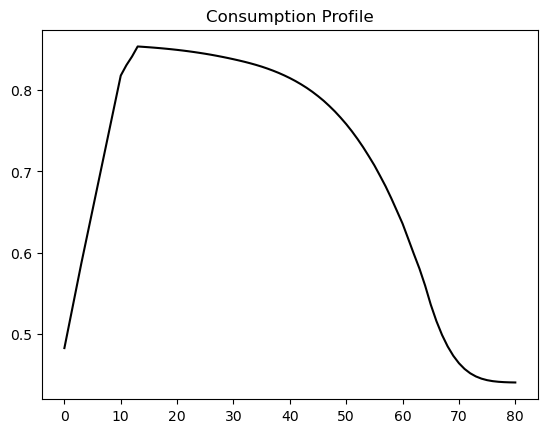

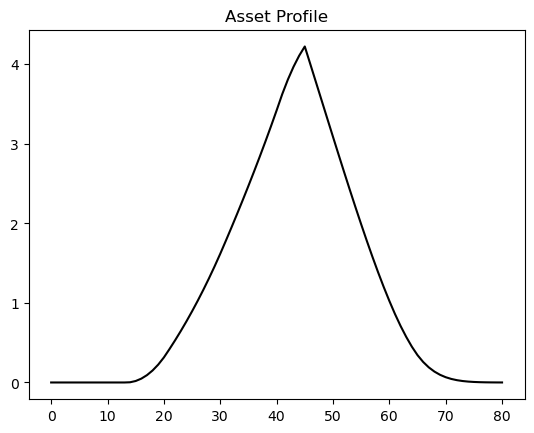

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# load age productivity profile and lifetable
age_profile = np.loadtxt('ageprod.txt')
age_profile = age_profile / np.mean(age_profile)
surv_rate = np.loadtxt('surv_rate.txt')

# economic parameters
maxage = 81
ret_age = 45
irate = 0.03
time_pref = irate
betta = 1.0 / (1.0 + time_pref)
sigma = 2.0
tau = 0.15
ben = 0.44
w = 1

amin = 0.0
amax = 50.0
na = 101

# set up the savings grid
agrid = np.linspace(amin, amax, na)

# pre-allocate
ap = np.zeros((maxage, na))
con = np.zeros((maxage, na))
c_new = np.zeros((maxage, na)) # implied consumption
astar = np.zeros((maxage, na)) # endogenous asset
a_bar = np.zeros(maxage) # a today correspodning to a'=0

# LAST PERIOD
j = maxage-1
# loop over (beginning-of-period) savings
for ia in range(na):
    # the household will consume all the remaining resources
    ap[j, ia] = 0.0
    con[j, ia] = (1.0 + irate) * agrid[ia] + ben

# RETIREMENT
for j in range(maxage-2, ret_age-1, -1):

    # EGM Step 1:
    # loop over savings choice
    for ia in range(na):
        # compute the RHS of the euler equation
        rhs = betta * surv_rate[j] * (1.0 + irate) * con[j + 1, ia] ** (-sigma)
        # compute the implied consumption
        c_new[j, ia] = rhs ** (-1.0 / sigma)
        # compute the implied beginning-of-period assets
        astar[j, ia] = (c_new[j, ia] + agrid[ia] - ben) / (1.0 + irate)

    # store the savings corresponding to the lowest grid point
    a_bar[j] = astar[j, 0]

    # EGM Step 2:
    # loop over beginning-of-period assets
    for ia in range(na):
        if agrid[ia] < a_bar[j]:  # if the borrowing constraint is binding
            con[j, ia] = ben + (1.0 + irate) * agrid[ia]
            ap[j, ia] = 0.0
        else:  # if the borrowing cosntraint is not binding
            con[j, ia] = np.interp(agrid[ia], astar[j, :], c_new[j, :])
            ap[j, ia] = (1.0 + irate) * agrid[ia] + ben - con[j, ia]

# WORKING AGE
for j in range(ret_age-1, -1, -1):

    # EGM Step 1:
    # loop over savings choice
    for ia in range(na):
        # compute the RHS of the euler equation
        rhs = betta * surv_rate[j] * (1.0 + irate) * con[j + 1, ia] ** (-sigma)
        # compute the implied consumption
        c_new[j, ia] = rhs ** (-1.0 / sigma)
        # compute the implied beginning-of-period assets
        astar[j, ia] = (c_new[j, ia] + agrid[ia] - (1 - tau) * w * age_profile[j]) / (1.0 + irate)

    # store the savings corresponding to the lowest grid point
    a_bar[j] = astar[j, 0]

    # EGM Step 2:
    # loop over beginning-of-period assets
    for ia in range(na):
        if agrid[ia] < a_bar[j]:  # if the borrowing constraint is binding
            con[j, ia] = (1 - tau) * w * age_profile[j] + (1.0 + irate) * agrid[ia]
            ap[j, ia] = 0.0
        else:  # if the borrowing cosntraint is not binding
            con[j, ia] = np.interp(agrid[ia], astar[j, :], c_new[j, :])
            ap[j, ia] = (1.0 + irate) * agrid[ia] + (1 - tau) * w * age_profile[j] - con[j, ia]

# LIFECYCLE PROFILES
a_profile = np.zeros(maxage)
con_profile = np.zeros(maxage)
ap_profile = np.zeros(maxage)

for j in range(maxage - 1):
    con_profile[j] = np.interp(a_profile[j], agrid, con[j, :])
    ap_profile[j] = np.interp(a_profile[j], agrid, ap[j, :])
    a_profile[j + 1] = ap_profile[j]

# last period
con_profile[maxage - 1] = np.interp(a_profile[maxage - 1], agrid, con[maxage - 1, :])

plt.figure()
plt.plot(np.arange(maxage), con_profile, color='black')
plt.title('Consumption Profile')

plt.figure()
plt.plot(np.arange(maxage), a_profile, color='black')
plt.title('Asset Profile')
plt.show()